In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import get_HEP_data as gHd

1 - Plot particles_events in a histogram with one entry per event

Event_0: mean(X) =  0.025 || mean(Y) =  0.006 || mean(Z) =  196.953
         strd(X) =  0.275 || strd(Y) =  0.305 || strd(Z) =  2.984
--------------------------------------------------------------------
Event_1: mean(X) = -0.053 || mean(Y) =  0.081 || mean(Z) =  106.100
         strd(X) =  0.178 || strd(Y) =  0.225 || strd(Z) =  0.067
--------------------------------------------------------------------
Event_2: mean(X) =  0.023 || mean(Y) =  0.020 || mean(Z) =  49.281
         strd(X) =  0.126 || strd(Y) =  0.087 || strd(Z) =  0.361
--------------------------------------------------------------------
Event_3: mean(X) =  0.009 || mean(Y) = -0.013 || mean(Z) =  61.058
         strd(X) =  0.000 || strd(Y) =  0.000 || strd(Z) =  0.000
--------------------------------------------------------------------
Event_4: mean(X) =  0.006 || mean(Y) =  0.014 || mean(Z) =  52.570
         strd(X) =  0.000 || strd(Y) =  0.000 || strd(Z) =  0.000
---------------------------------------------------------

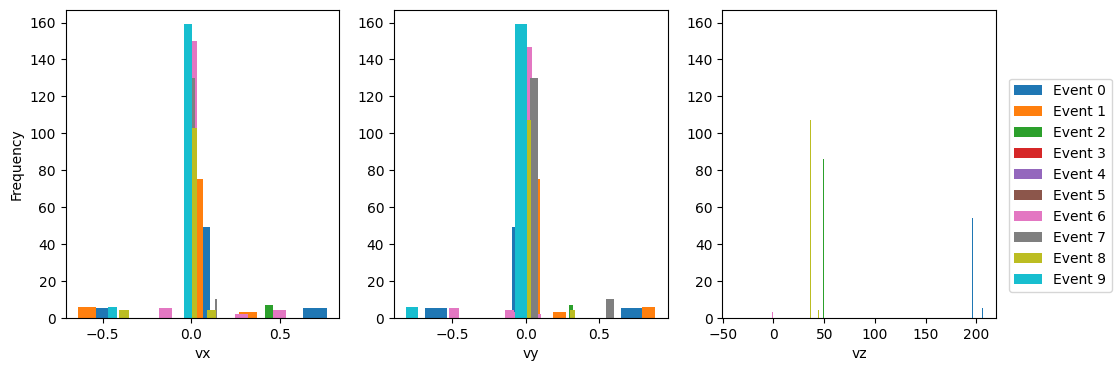

In [8]:
particles = gHd.get_particles()

fig, (ax_x, ax_y, ax_z) = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

ax_x.set_xlabel('vx')
ax_x.set_ylabel('Frequency')
#ax_x.set_xscale('log')
ax_y.set_xlabel('vy')
#ax_y.set_xscale('log')
ax_z.set_xlabel('vz')

for n in range(10):
    # get data for single event
    particles_event = particles[particles['event_id'] == n].copy()
    
    # applying conditions we talked about on the call
    particles_event = particles_event[abs(particles_event['vx']) < 1]
    particles_event = particles_event[abs(particles_event['vy']) < 1]
    particles_event['pT'] = np.sqrt(particles_event['px']**2 + particles_event['py']**2)
    particles_event = particles_event[particles_event['pT'] > 1]

    ax_x.hist(particles_event['vx'], bins=10, label=f"Event {n}")
    ax_y.hist(particles_event['vy'], bins=10)
    ax_z.hist(particles_event['vz'], bins=10)

    print(f"Event_{n}: mean(X) = {np.mean(particles_event['vx']) : .3f} || mean(Y) = {np.mean(particles_event['vy']) : .3f} || mean(Z) = {np.mean(particles_event['vz']) : .3f}")
    print(f"         strd(X) = {np.std(particles_event['vx']) : .3f} || strd(Y) = {np.std(particles_event['vy']) : .3f} || strd(Z) = {np.std(particles_event['vz']) : .3f}")
    print("--------------------------------------------------------------------")

fig.legend(loc='center right')

2 - plot particle pT before cut (to confirm that it is in GeV)

Event_0 pT median: 0.5055368463075953 
Event_1 pT median: 0.715948781872175 
Event_2 pT median: 0.527089628912666 
Event_3 pT median: 0.6794950809299882 
Event_4 pT median: 0.5027041738684713 
Event_5 pT median: 0.45127344003687714 
Event_6 pT median: 0.4413784612493262 
Event_7 pT median: 0.49365393350025133 
Event_8 pT median: 0.5196363063620126 
Event_9 pT median: 0.4852466869801117 


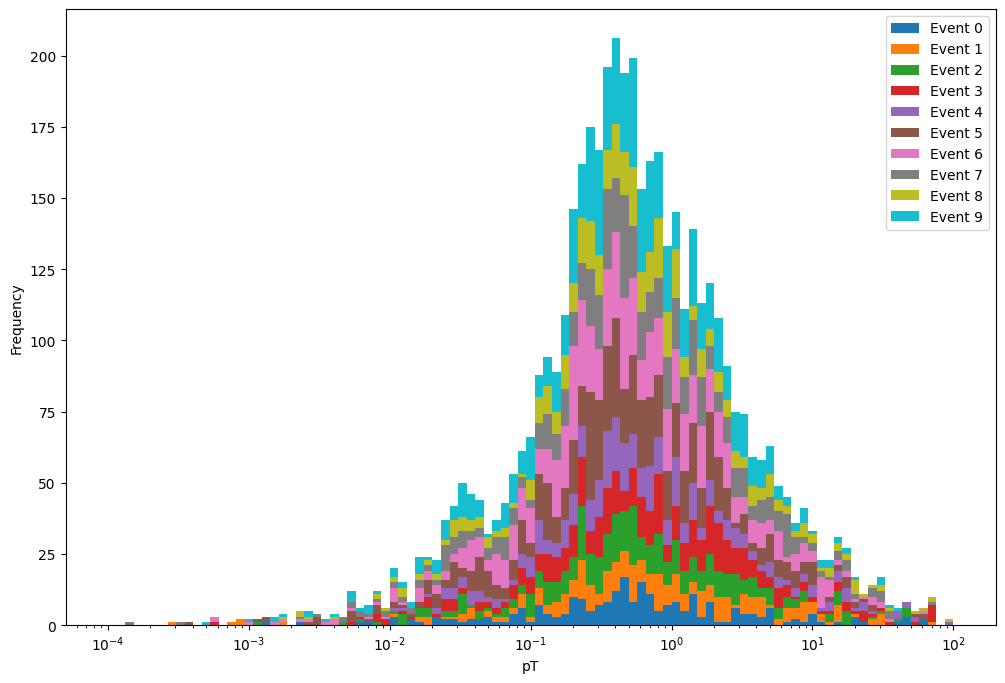

In [9]:
particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)

fig, ax = plt.subplots(figsize=(12,8))

pT_data = []
pT_names = []

for n in range(10):
    # get data for single event
    globals()[f"event_{n}"] = particles[particles['event_id'] == n].copy()
    pT_data.append(globals()[f"event_{n}"]['pT'])
    pT_names.append(f"Event {n}")
    pT_mean = np.median(globals()[f"event_{n}"]['pT'])
    print(f'Event_{n} pT median: {pT_mean} ')

logbins = np.logspace(-4,2,100)
ax.hist(pT_data, bins = logbins, stacked=True, label=pT_names)

ax.set_xscale('log')
ax.set_xlabel('pT')
ax.set_ylabel('Frequency')
ax.legend()

It is in GeV as the soft peak is around pT = 0.5 for all the events. The tail extends to $10^2$ which suggests it is also in GeV

3&4 - plot number of tracker and calo hits for those passing vx,vy and pT cuts

(0.0, 4500.0)

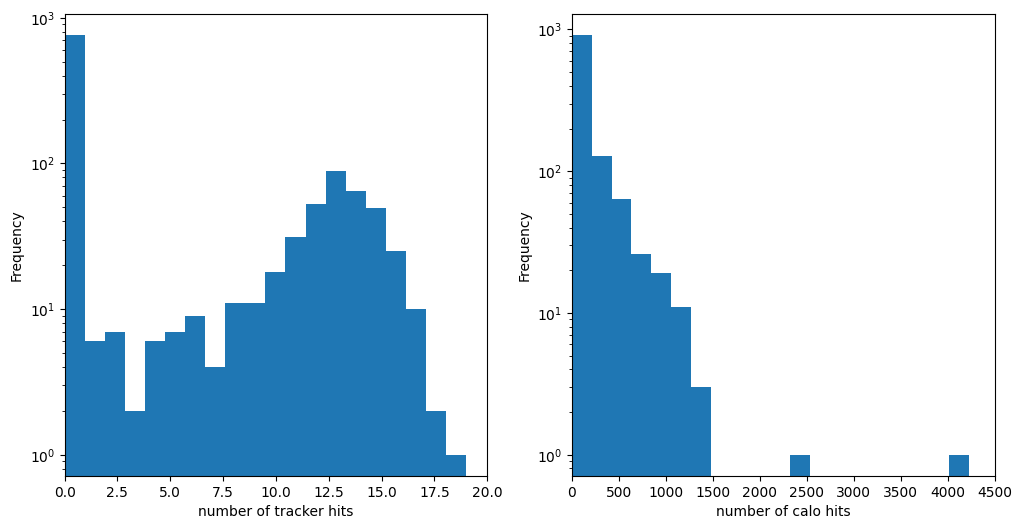

In [10]:
fig, (ax_t,ax_c) = plt.subplots(1,2,figsize=(12,6))

# applying conditions we talked about on the call
particles_event = particles[abs(particles['vx']) < 1]
particles_event = particles_event[abs(particles_event['vy']) < 1]
particles_event = particles_event[particles_event['pT'] > 1]

ax_t.hist(particles_event['num_tracker_hits'], bins=20)
ax_c.hist(particles_event['num_calo_hits'], bins=20)

ax_t.set_yscale('log')
ax_c.set_yscale('log')

ax_t.set_ylabel('Frequency')
ax_c.set_ylabel('Frequency')

ax_t.set_xlabel('number of tracker hits')
ax_c.set_xlabel('number of calo hits')

ax_t.set_xlim(0,20)
ax_c.set_xlim(0,4500)

5 - one event at a time - draw particles and their hits in the track - connect with line of different color per particle (neutral will not have any tracker)

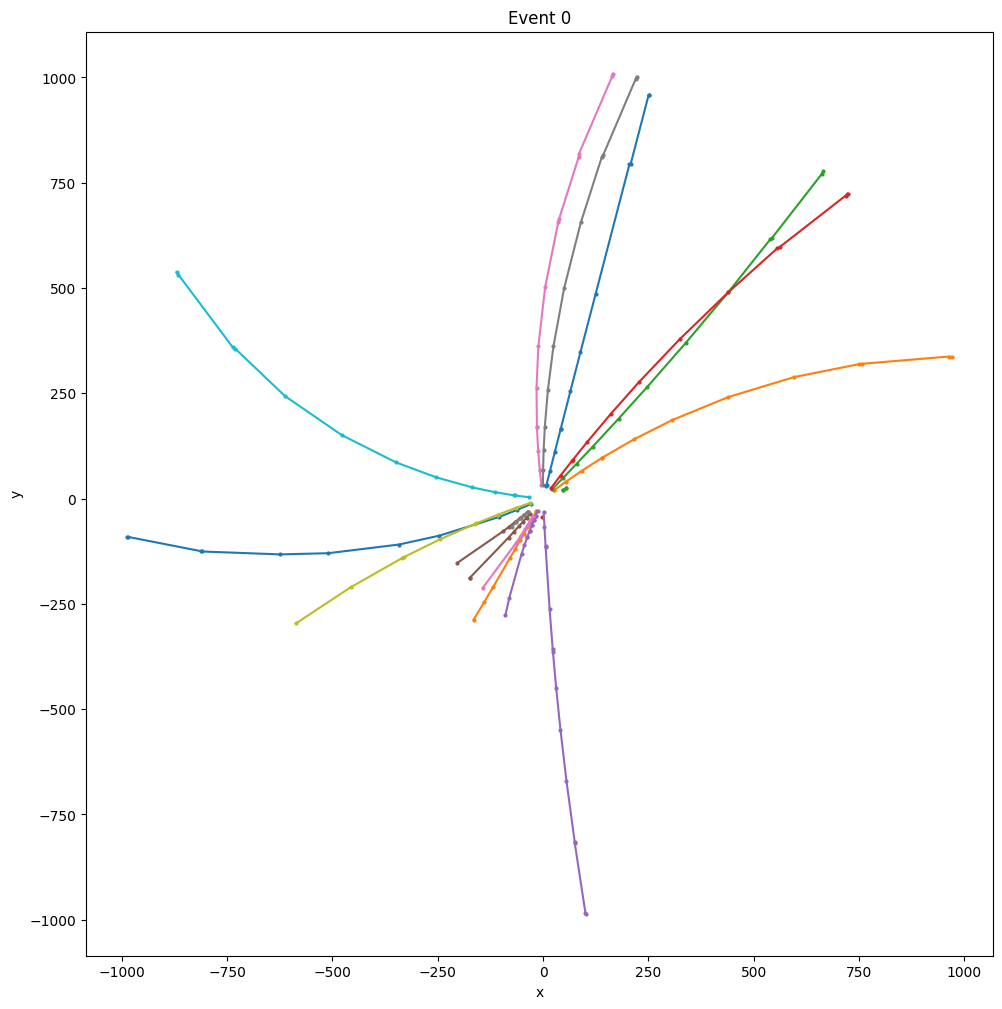

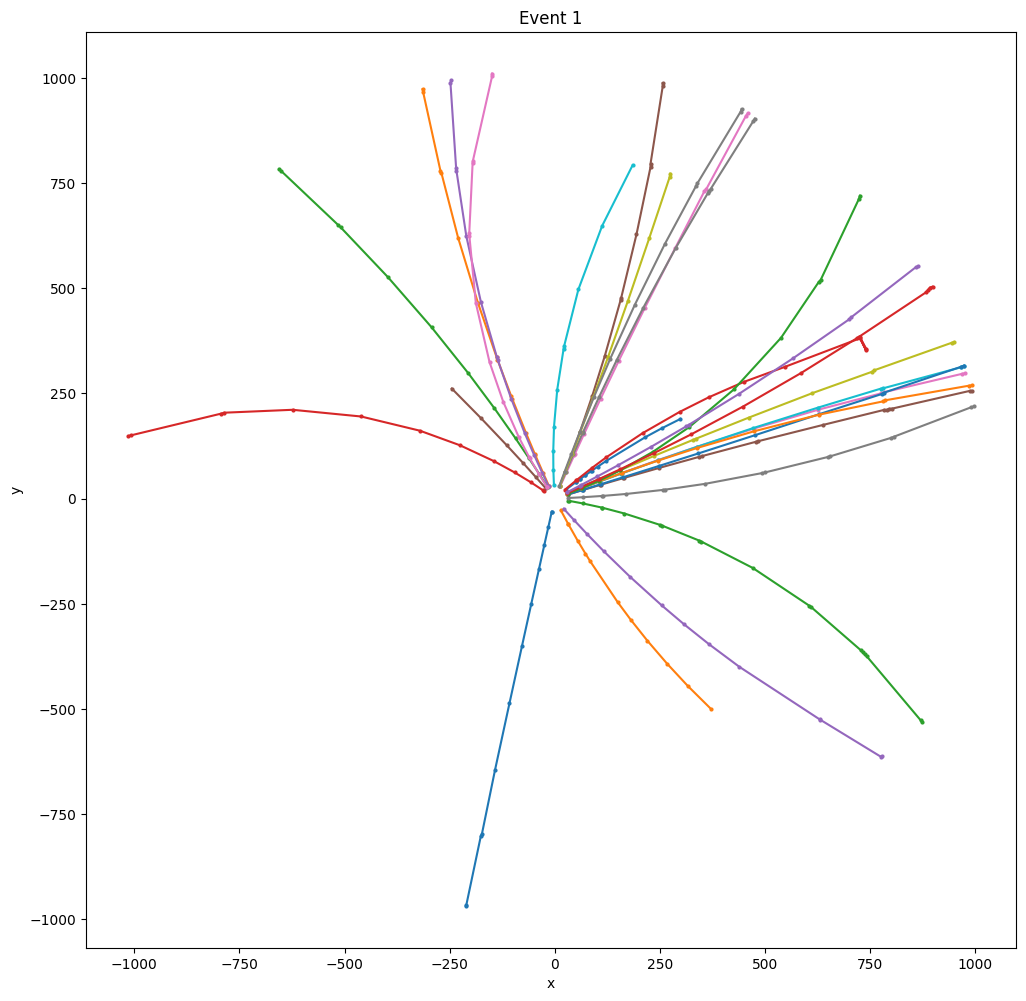

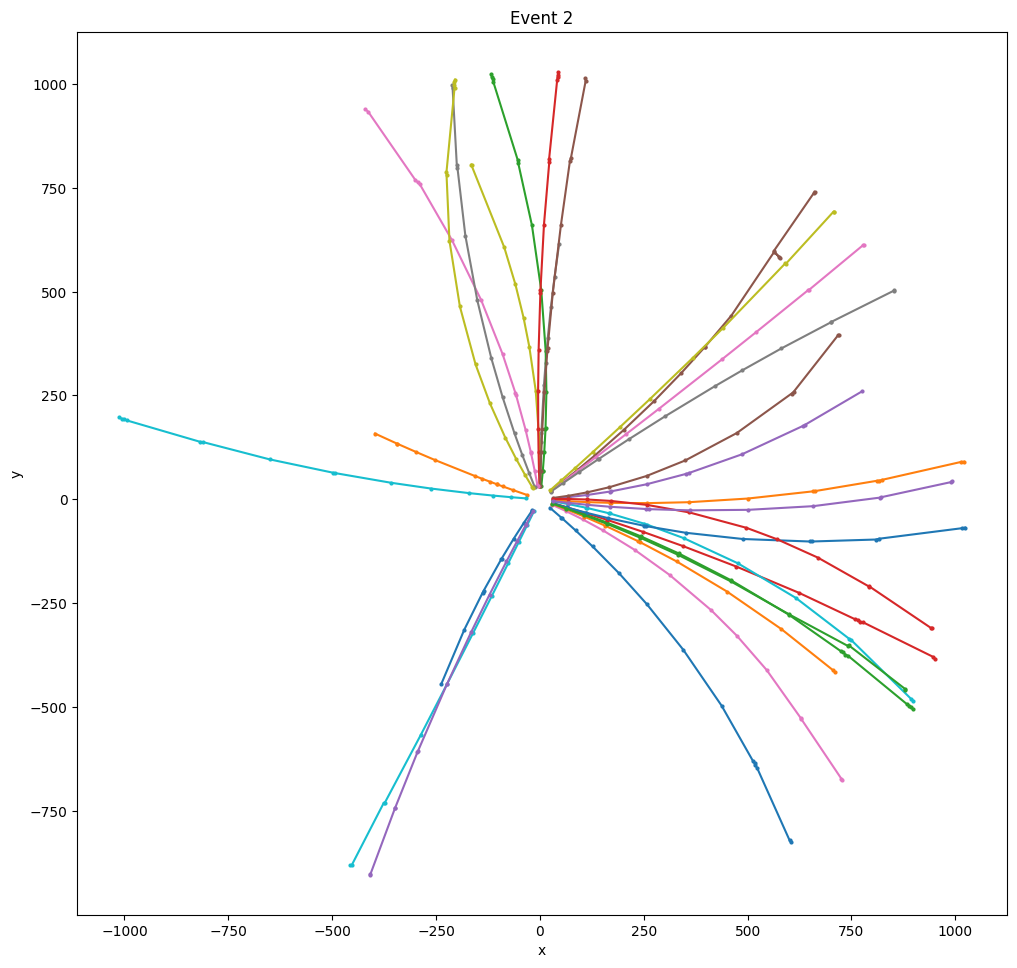

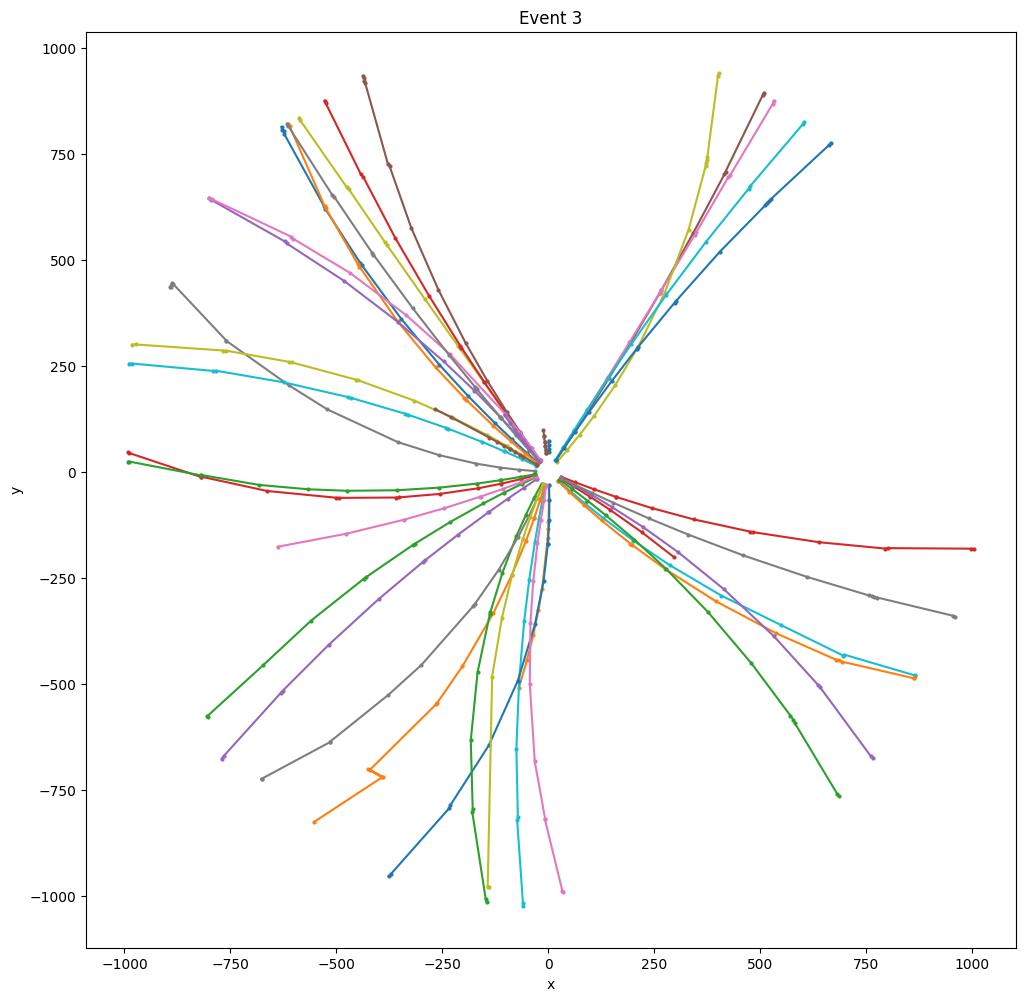

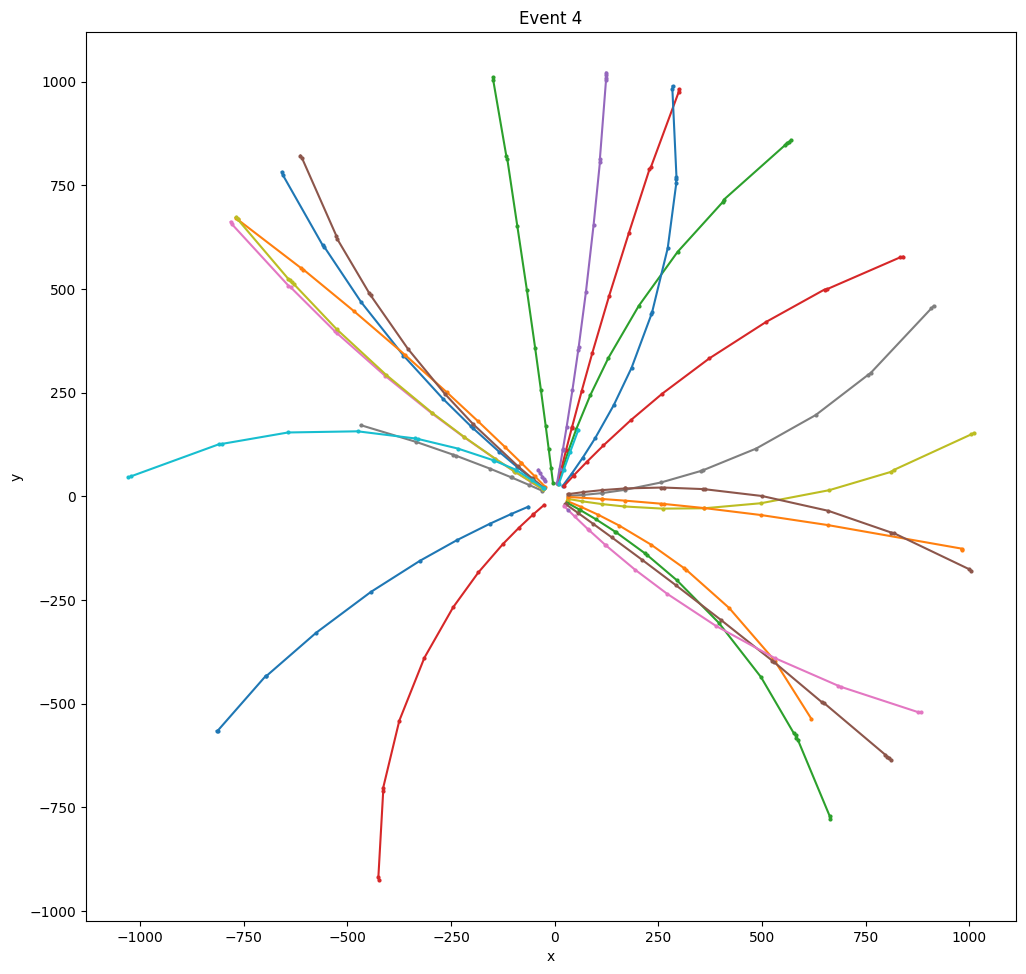

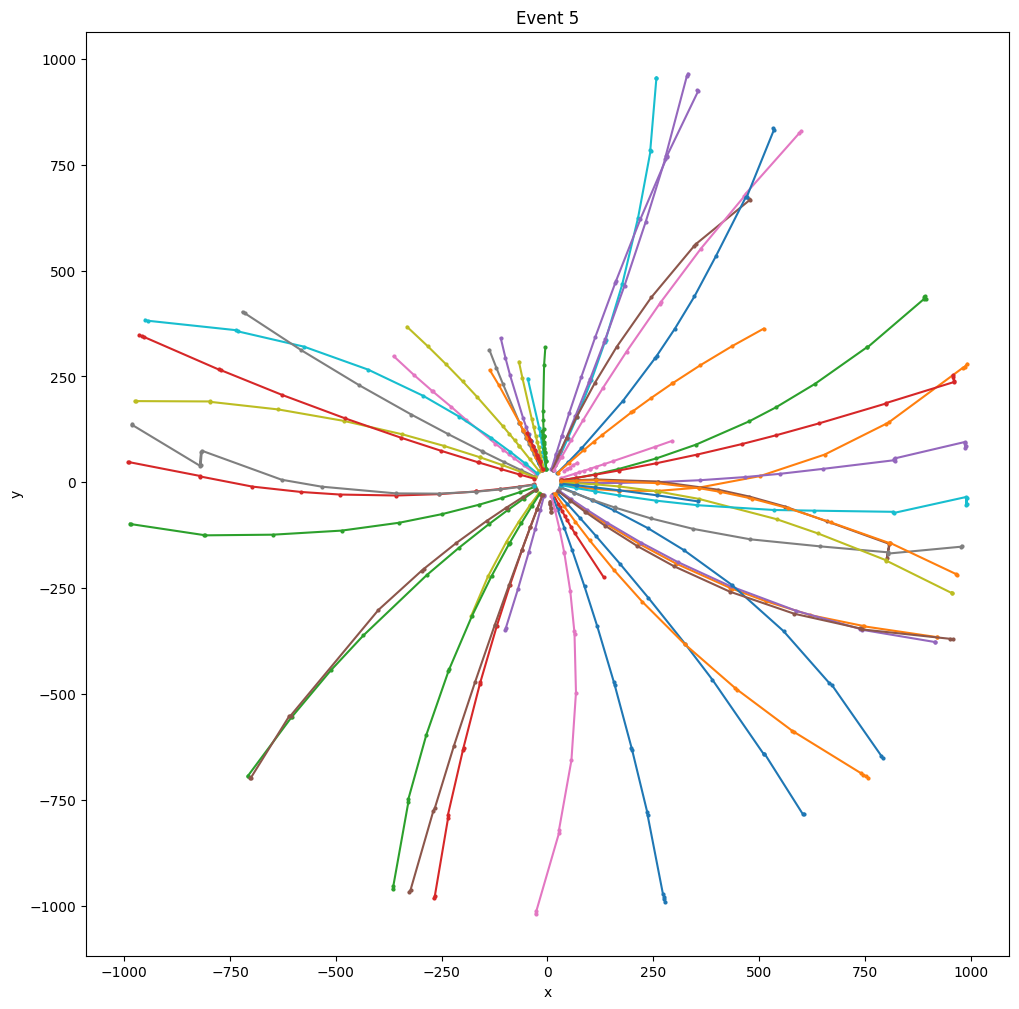

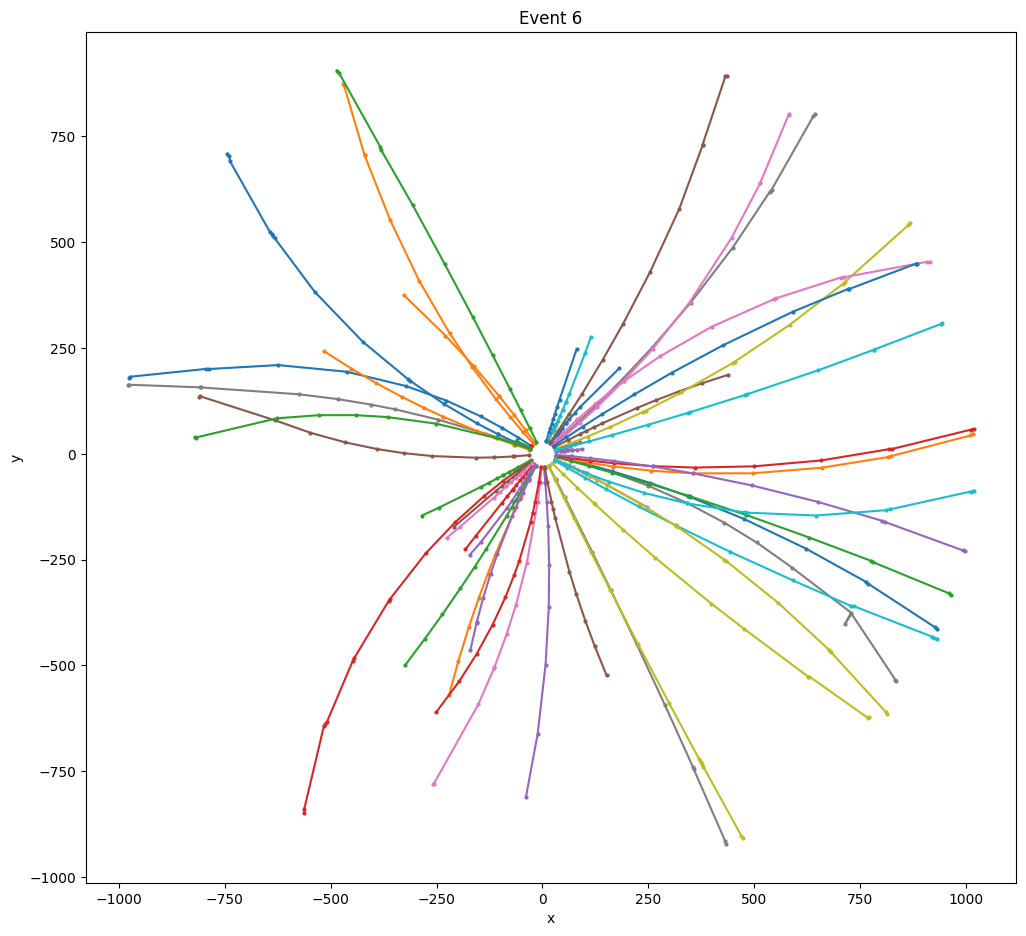

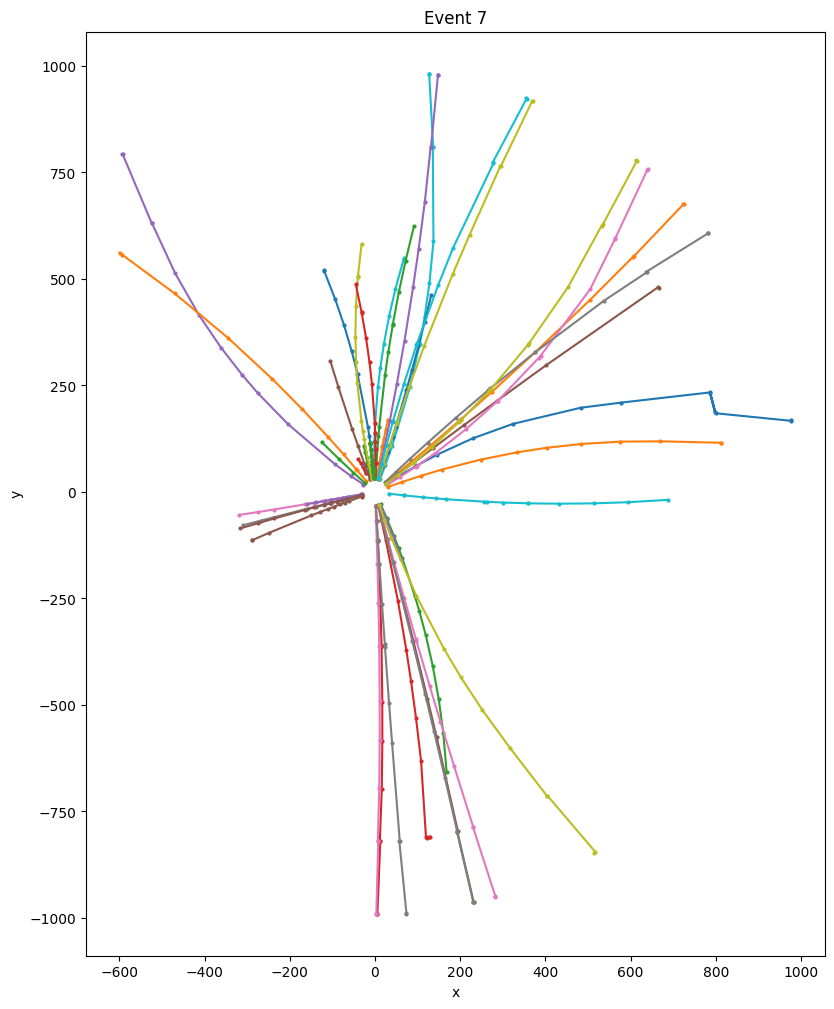

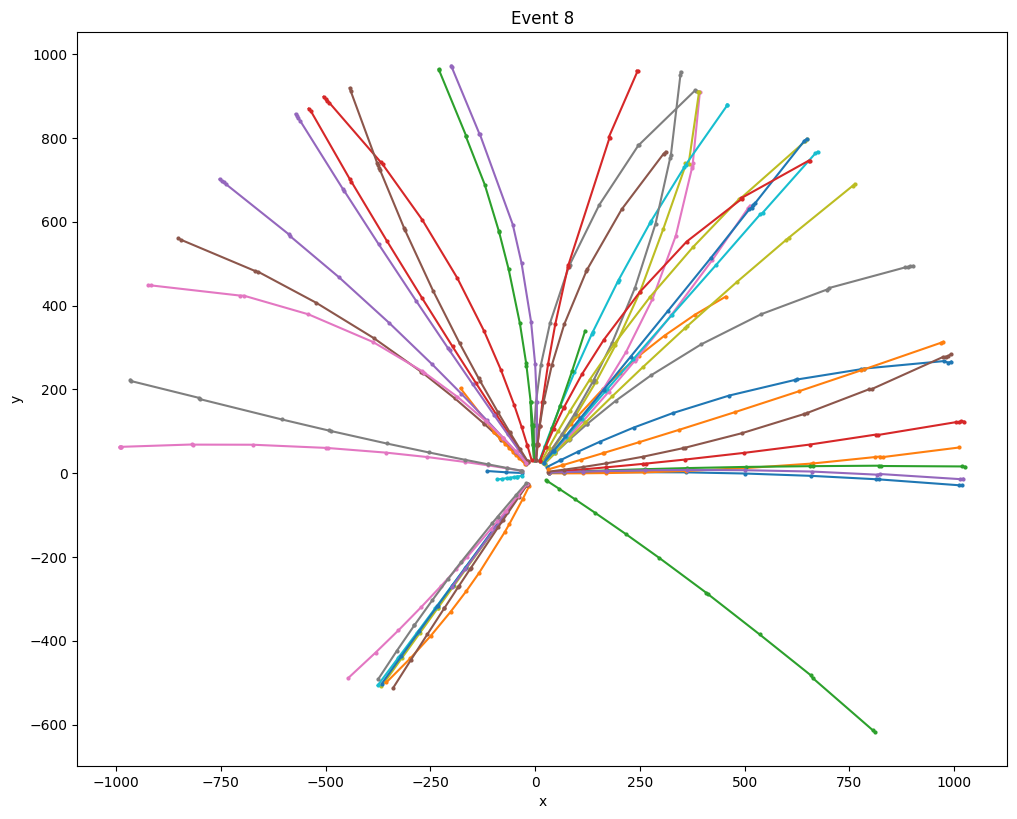

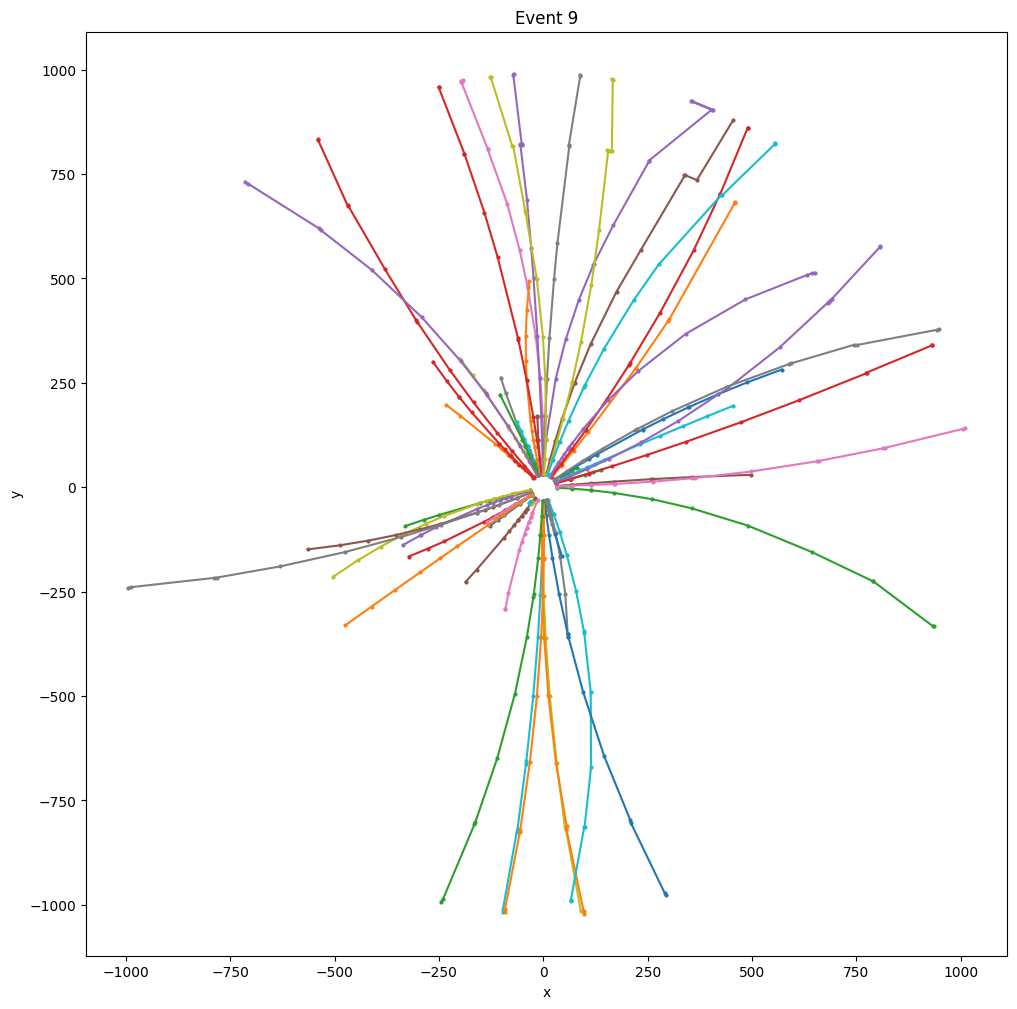

In [11]:
for n in range(10):
    # retreaving data:
    particles = gHd.get_particles()
    tracker_hits = gHd.get_tracker_hits()
    particles = particles[particles['event_id'] == n].copy()
    tracker_hits = tracker_hits[tracker_hits['event_id'] == n].copy()

    # setting conditions
    particles = particles[abs(particles['vx']) < 1]
    particles = particles[abs(particles['vy']) < 1]
    particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
    particles = particles[particles['pT'] > 1]

    # getting tracker hits that match the particles
    particles_id = particles["particle_id"].unique()
    tracker_hits = tracker_hits[tracker_hits["particle_id"].isin(particles_id)]

    # Finding the radius from the center of detector:
    tracker_hits['r'] = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)
    # Ordering data with respect to the radius so that straight lines are plotted
    tracker_hits = tracker_hits.sort_values(by=['particle_id', 'r'])

    fig, ax = plt.subplots(figsize=(12, 12))

    for particle_id, group_of_hits in tracker_hits.groupby('particle_id'):
        # particle_id = id of particle in current group
        # group_of_hits = data in that group (x,y,r)
        
        ax.plot(
            group_of_hits['x'],
            group_of_hits['y'],
            marker='o', 
            markersize=2, 
            linestyle='-', 
            label=f'ID = {particle_id}'
        )
    ax.set_title(f"Event {n}")
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


if you get that to work, extend into the calo - don't connect the dots, but just draw the dots the same color (bonus, size proportional to energy)

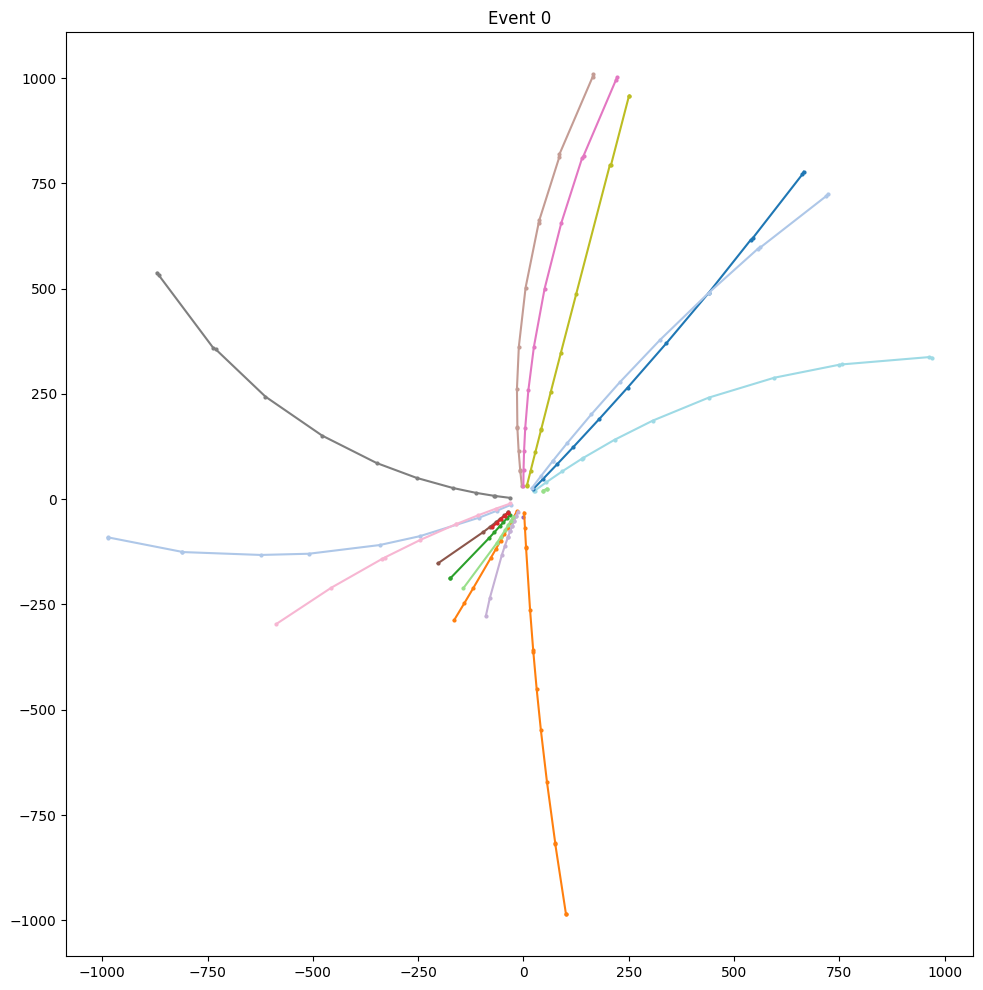

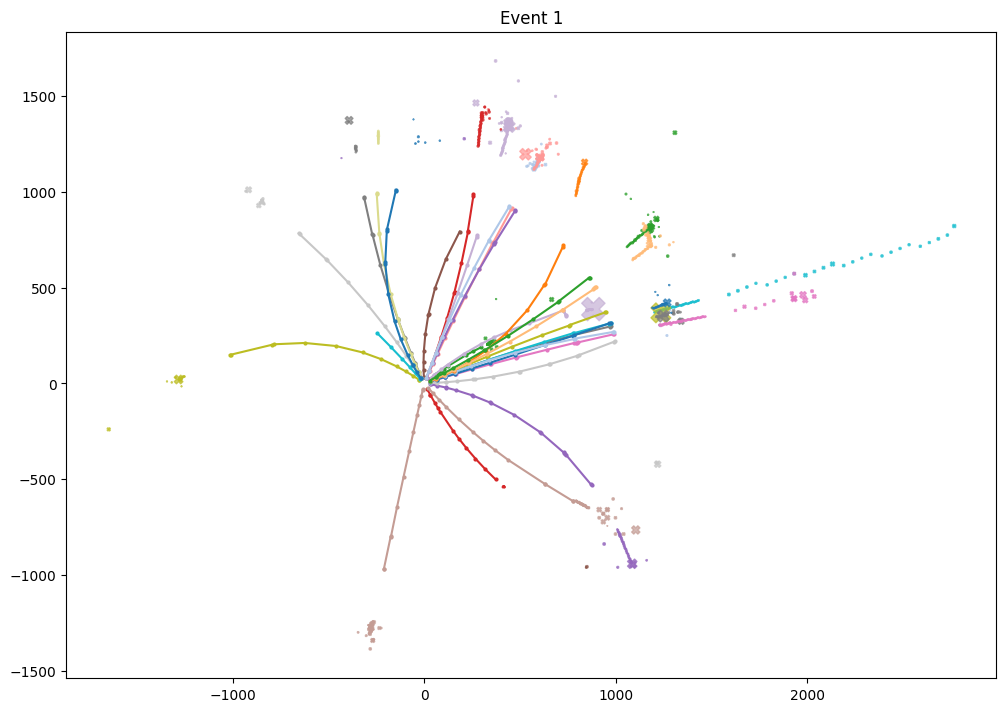

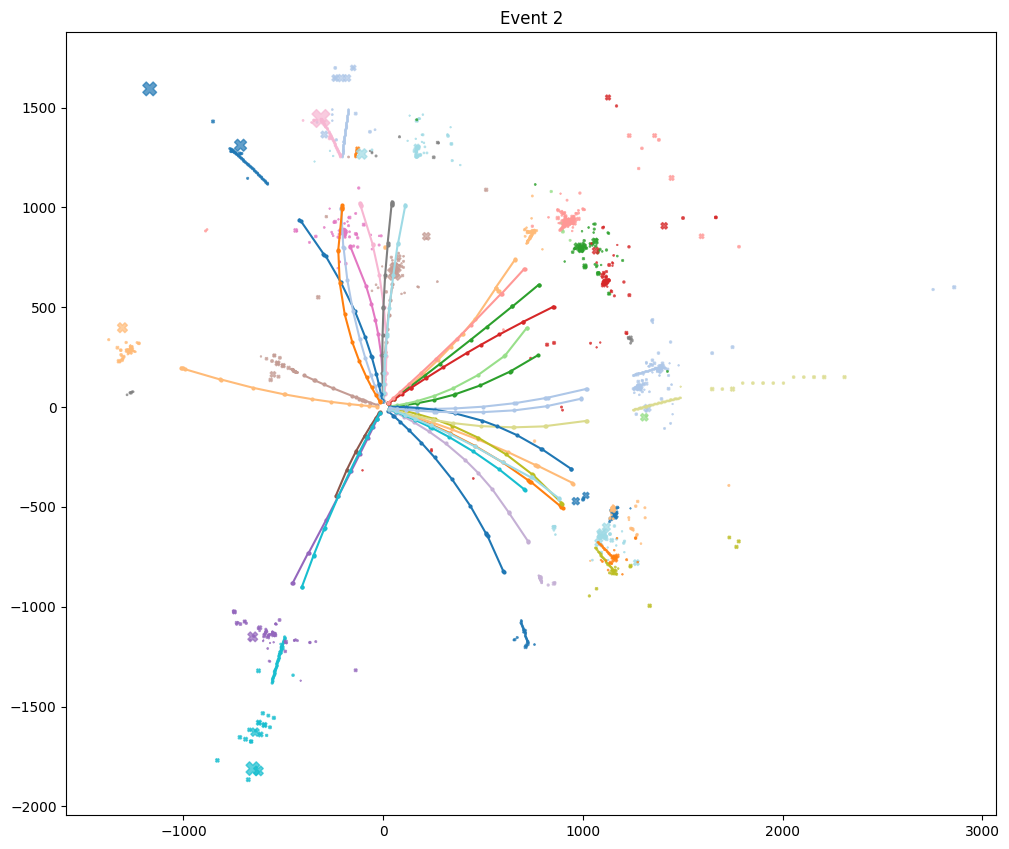

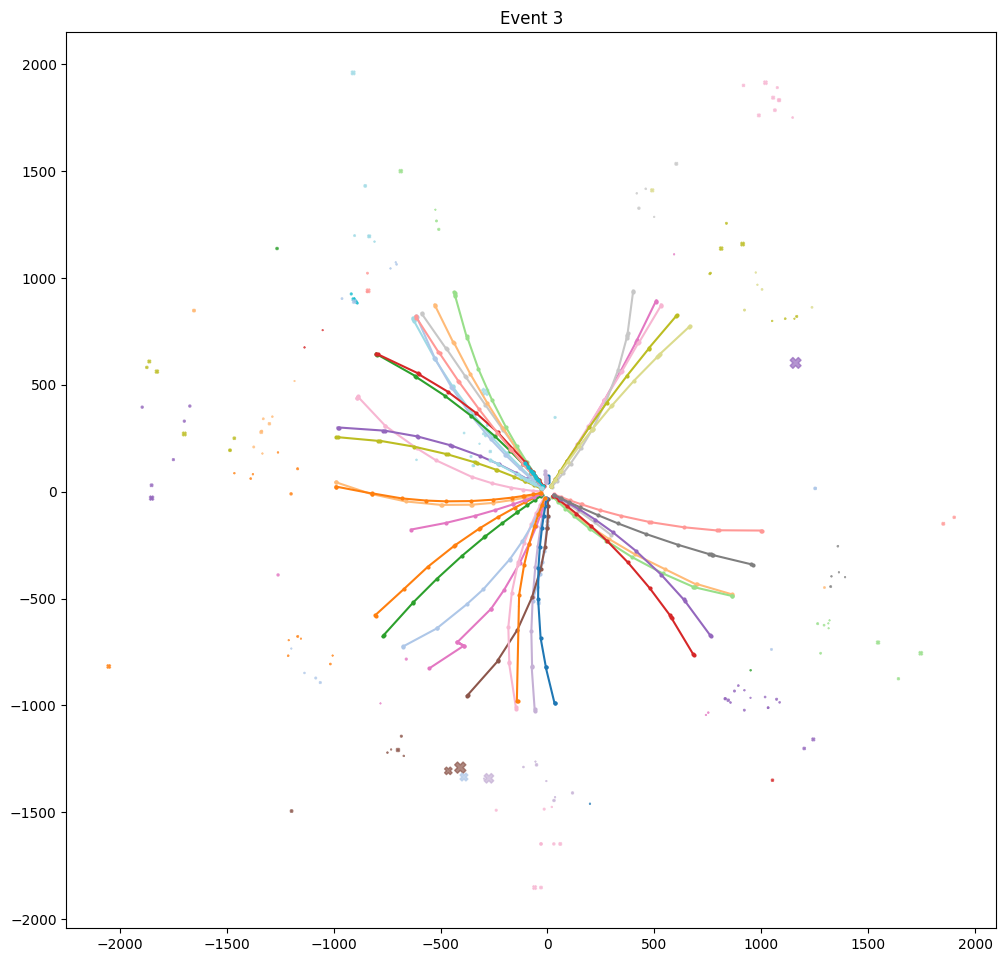

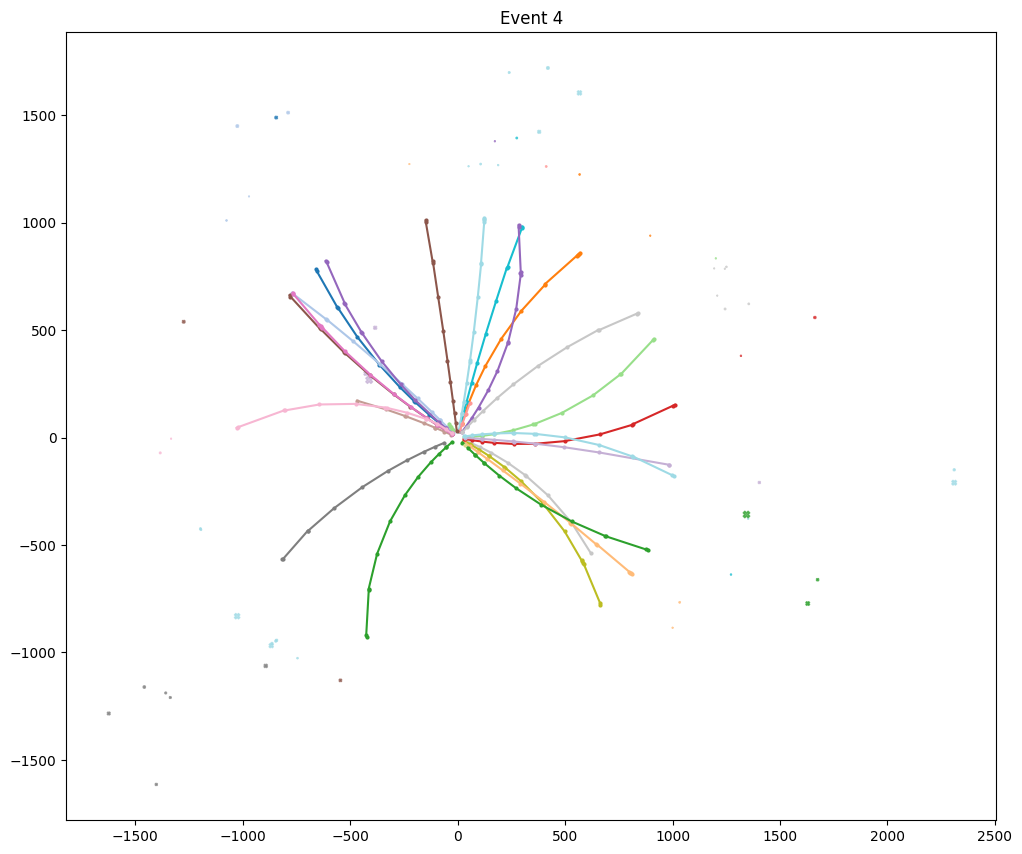

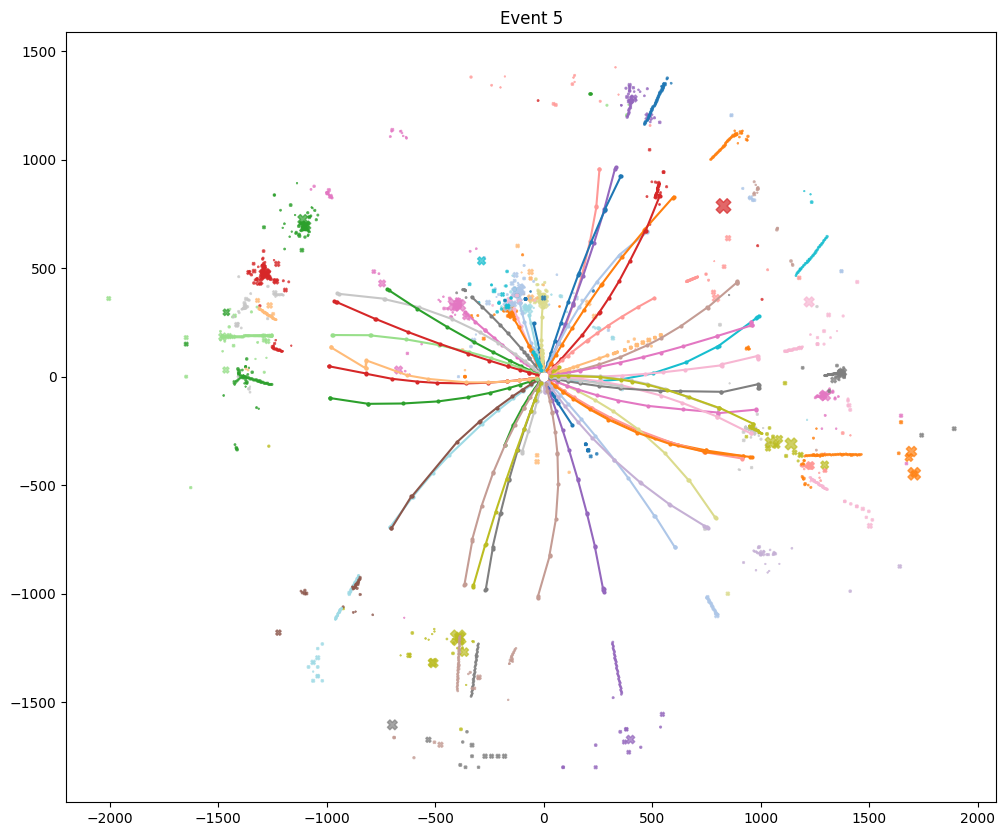

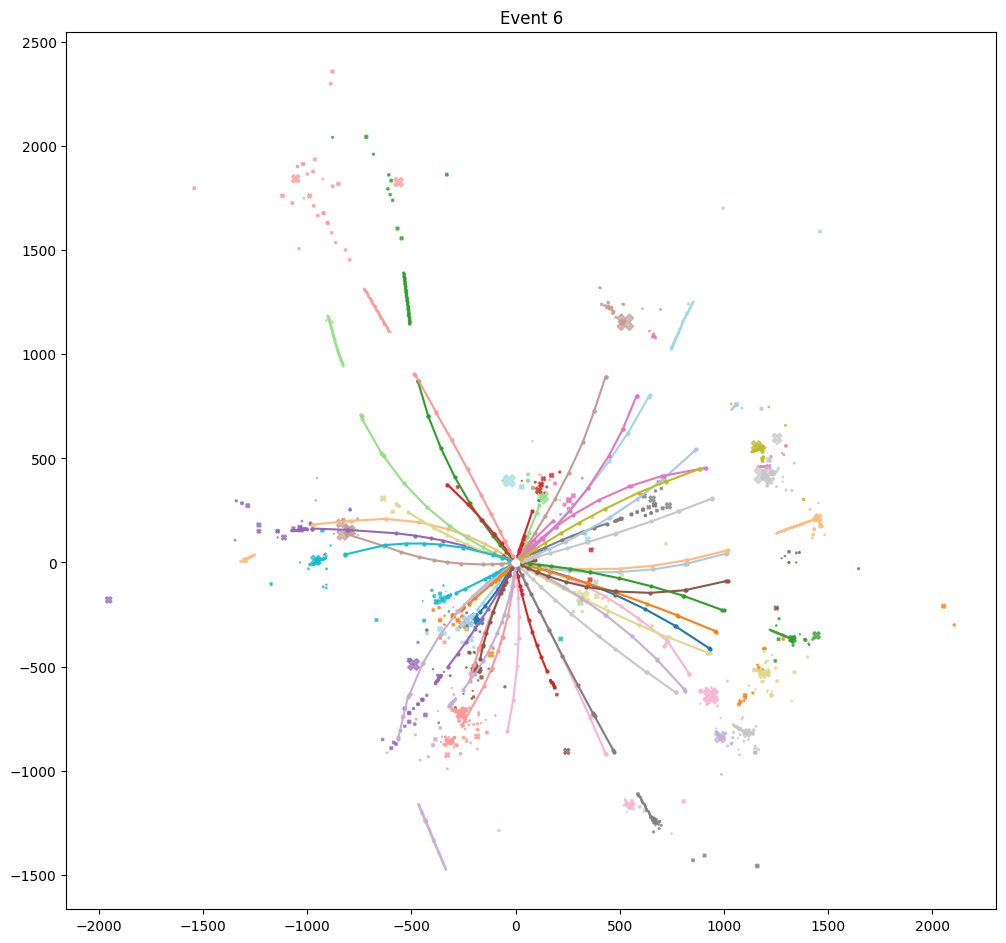

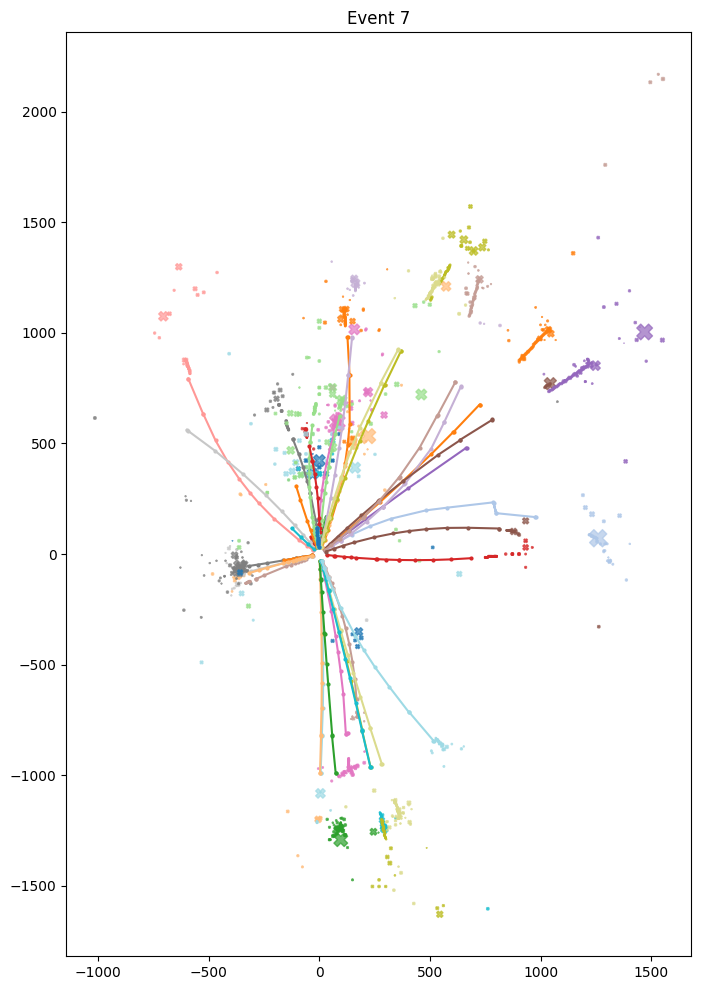

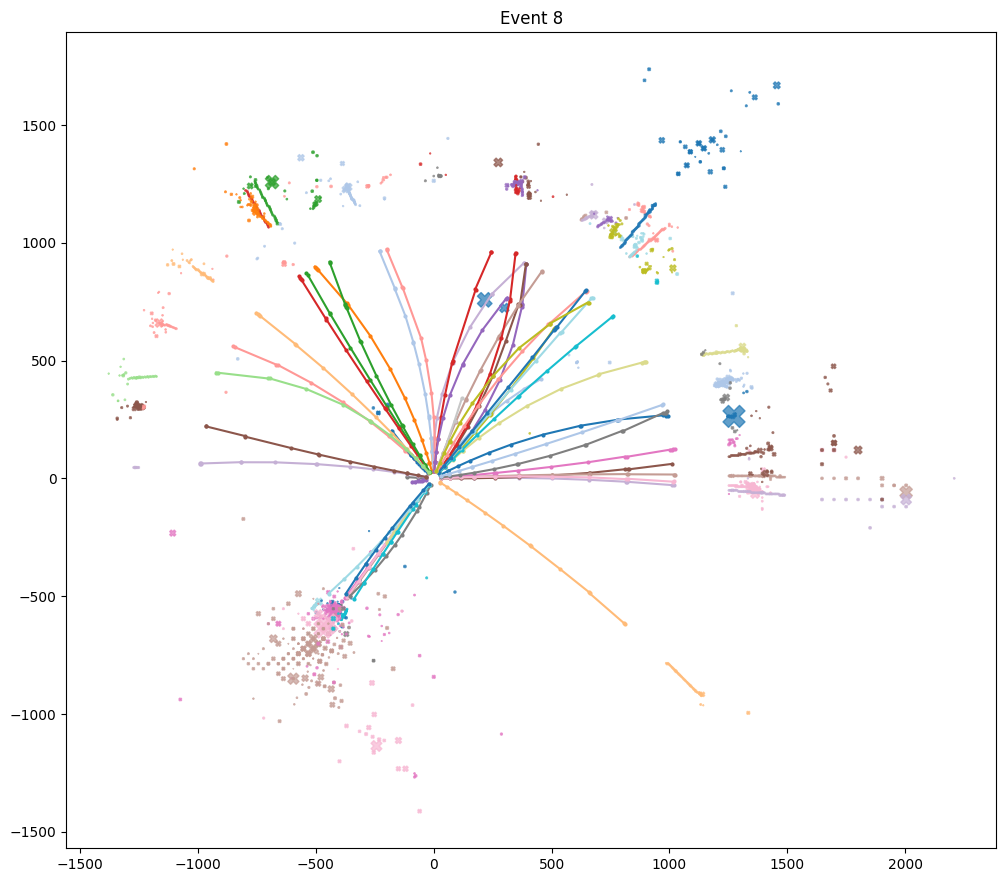

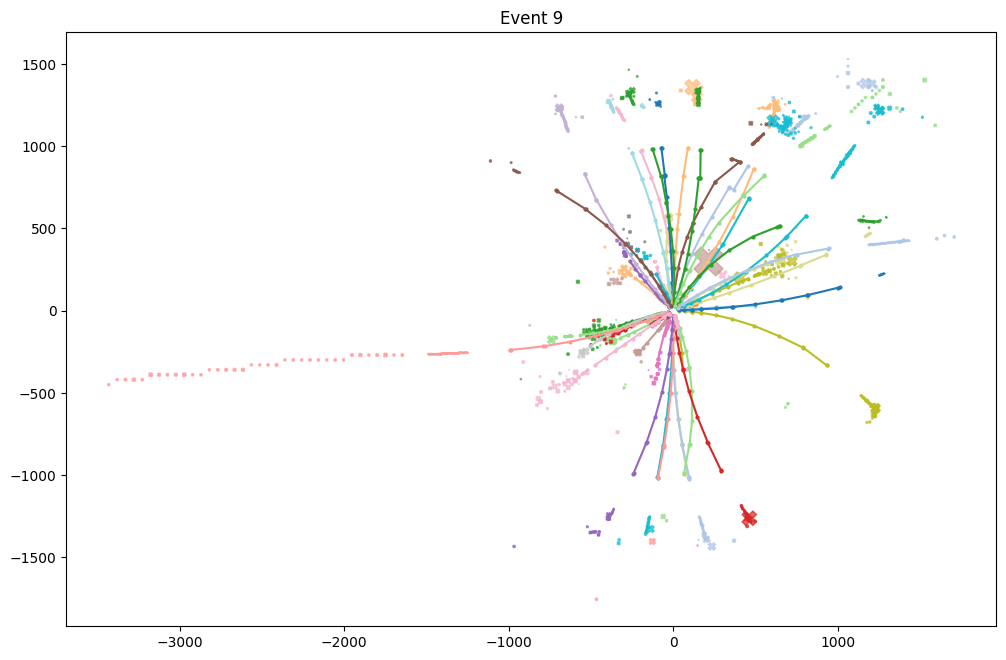

In [ ]:
for n in range(10):
    # retreaving data:
    particles = gHd.get_particles()
    tracker_hits = gHd.get_tracker_hits()
    calo_hits = gHd.get_calo_hits()
    particles = particles[particles['event_id'] == n].copy()
    tracker_hits = tracker_hits[tracker_hits['event_id'] == n].copy()
    calo_hits = calo_hits[calo_hits['event_id'] == n].copy()

    # setting conditions
    particles = particles[abs(particles['vx']) < 1]
    particles = particles[abs(particles['vy']) < 1]
    particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
    particles = particles[particles['pT'] > 1]

    # removing neutral charges:
    particles_id = particles[particles['charge'] != 0]
    # getting tracker hits that match the particles
    particles_id = particles_id["particle_id"].unique()
    tracker_hits = tracker_hits[tracker_hits["particle_id"].isin(particles_id)]

    # Finding the radius from the center of detector:
    tracker_hits['r'] = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)
    # Ordering data with respect to the radius so that straight lines are plotted
    tracker_hits = tracker_hits.sort_values(by=['particle_id', 'r'])

    fig, ax = plt.subplots(figsize=(12, 12))

    # creating colourmap to match the calo and tracker data
    cmap = plt.colormaps['tab20']
    base_colors = cmap.colors
    num_base_colors = len(base_colors)
    particle_color_map = {
        pid: base_colors[i % num_base_colors] for i, pid in enumerate(particles_id)
    }

    for particle_id, group_of_hits in tracker_hits.groupby('particle_id'):
        # particle_id = id of particle in current group
        # group_of_hits = data in that group (x,y,r)
        
        color = particle_color_map.get(particle_id)

        ax.plot(
            group_of_hits['x'],
            group_of_hits['y'],
            marker='o', 
            markersize=2, 
            linestyle='-',
            color=color,
            label=f'ID = {particle_id}'
        )
    
    calo_hits = calo_hits.explode(['contrib_particle_ids', 'contrib_energies'])
    calo_hits = calo_hits[calo_hits['contrib_particle_ids'].isin(particles_id)]

    calo_colors = calo_hits['contrib_particle_ids'].map(particle_color_map)
    calo_size = pd.to_numeric(calo_hits['contrib_energies']) * 5000

    ax.scatter(
            calo_hits['x'],
            calo_hits['y'],
            s=calo_size,
            c=calo_colors,
            marker='X',
            alpha=0.7
        )

    ax.set_title(f"Event {n}")
    ax.set_aspect('equal')
    #ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))